In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [6]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [7]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [8]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [9]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [10]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [11]:
print(lr.classes_)

['Bream' 'Smelt']


In [12]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [13]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [14]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [15]:
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [16]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [17]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [18]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [20]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7815126050420168
0.8


c:\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [21]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7815126050420168
0.8


c:\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [22]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.8067226890756303
0.825


In [23]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [24]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

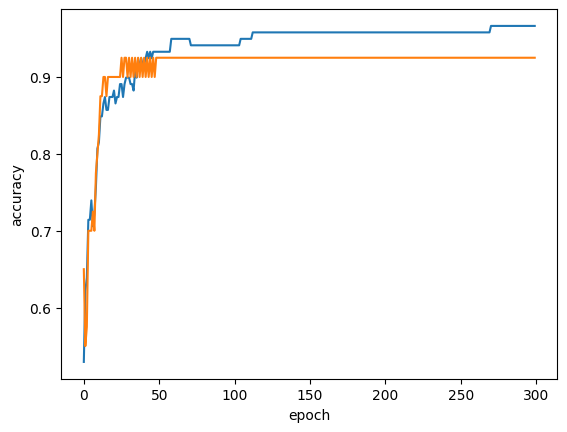

In [25]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [26]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


## 과제

#### 1번 과제

과제 설명: 로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력

In [27]:
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [29]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [30]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [32]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.8067226890756303
0.85


In [33]:
print(lr.predict(test_scaled[:5]))

proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.004 0.091 0.545 0.008 0.28  0.061 0.01 ]
 [0.    0.061 0.127 0.002 0.087 0.722 0.001]
 [0.009 0.009 0.223 0.569 0.17  0.006 0.013]
 [0.061 0.077 0.527 0.036 0.257 0.003 0.04 ]
 [0.004 0.03  0.664 0.026 0.245 0.018 0.013]]


In [34]:
import numpy as np

test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_scaled2 = ss.transform(test_data)

print(lr.predict(test_scaled2))

['Bream' 'Smelt' 'Pike' 'Perch' 'Bream']


c:\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
print( lr.classes_)
proba = lr.predict_proba(test_scaled2)
print(np.round(proba, decimals=3))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.317 0.094 0.268 0.055 0.202 0.001 0.063]
 [0.    0.055 0.145 0.002 0.094 0.702 0.001]
 [0.008 0.    0.378 0.586 0.011 0.    0.017]
 [0.01  0.074 0.581 0.015 0.284 0.019 0.017]
 [0.576 0.074 0.23  0.001 0.051 0.    0.068]]


결과: bream, smelt, pike, perch, bream으로 예측

#### 2번 과제

과제 설명: SGD classifier 모델을 훈련시키고 최적의 에포크 값을 찾기

In [37]:
fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

#from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)


In [38]:
#from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [40]:
#from sklearn.linear_model import SGDClassifier
sc10=SGDClassifier(loss='hinge', max_iter=10, tol = None, random_state=42)
sc10.fit(train_scaled,train_target)
print(sc10.score(train_scaled,train_target))
print(sc10.score(test_scaled,test_target))

0.8067226890756303
0.875


In [52]:
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [59]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

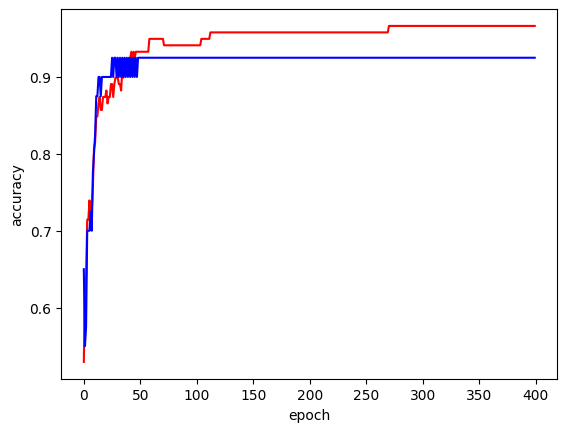

In [60]:
plt.plot(train_score, 'r')
plt.plot(test_score, 'b')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

70~100정도에서 오차가 작지만 정확도는 250쯤에서부터 높은 것 같다

In [49]:
sc300=SGDClassifier(loss='hinge', max_iter=300, tol = None, random_state=42)
sc300.fit(train_scaled,train_target)
print(sc300.score(train_scaled,train_target))
print(sc300.score(test_scaled,test_target))

0.8907563025210085
0.9


In [55]:
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [63]:
for _ in range(0,300):
    sc300.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc300.score(train_scaled,train_target))
    test_score.append(sc300.score(test_scaled,test_target))

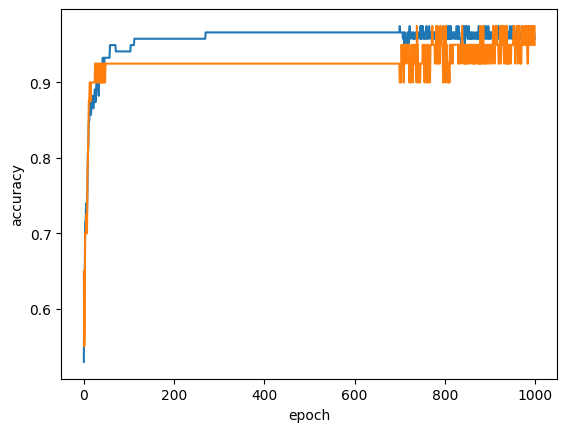

In [64]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

100~300 정도로 보인다

In [65]:
print("10: ", np.round(sc10.score(train_scaled,train_target),3), np.round(sc10.score(test_scaled,test_target),3))
print("300: ", np.round(sc300.score(train_scaled,train_target),3), np.round(sc300.score(test_scaled,test_target),3))

10:  0.807 0.875
300:  0.958 0.95


epoch 300번인 쪽이 더 정확하다